In [1]:
import os
import re
import h5py
import time
import joblib
import numpy as np
import pandas as pd
from pathlib import Path

import torch
from transformers import AutoTokenizer, AutoModel

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [2]:
# =========================
# Đường dẫn dữ liệu gốc
# =========================
DATA_PATH = Path("/kaggle/input/datasets/rmisra/news-category-dataset/News_Category_Dataset_v3.json")

# =========================
# Thư mục lưu kết quả
# =========================
RESULT_DIR = Path("/kaggle/working/bert_linearsvc_pipeline")
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("Data path:", DATA_PATH)
print("Result dir:", RESULT_DIR)

Data path: /kaggle/input/datasets/rmisra/news-category-dataset/News_Category_Dataset_v3.json
Result dir: /kaggle/working/bert_linearsvc_pipeline


In [3]:
df = pd.read_json(DATA_PATH, lines=True)

print("Original shape:", df.shape)
display(df.head())
print(df.columns)

Original shape: (209527, 6)


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


Index(['link', 'headline', 'category', 'short_description', 'authors', 'date'], dtype='object')


In [4]:
# =========================
# Chỉ giữ các cột cần thiết
# =========================
df = df[["category", "headline", "short_description"]].copy()

df["headline"] = df["headline"].fillna("").astype(str)
df["short_description"] = df["short_description"].fillna("").astype(str)
df["category"] = df["category"].fillna("").astype(str)

# =========================
# Tạo text gốc
# =========================
df["text"] = df["headline"] + " " + df["short_description"]

# Xóa dòng text rỗng
df = df[df["text"].str.strip() != ""].copy()

print("Shape after text creation:", df.shape)
display(df.head())

Shape after text creation: (209522, 4)


,category,headline,short_description,text
0,U.S. NEWS,Over 4 Million Americans Roll Up Sleeves For O...,Health experts said it is too early to predict...,Over 4 Million Americans Roll Up Sleeves For O...
1,U.S. NEWS,"American Airlines Flyer Charged, Banned For Li...",He was subdued by passengers and crew when he ...,"American Airlines Flyer Charged, Banned For Li..."
2,COMEDY,23 Of The Funniest Tweets About Cats And Dogs ...,"""Until you have a dog you don't understand wha...",23 Of The Funniest Tweets About Cats And Dogs ...
3,PARENTING,The Funniest Tweets From Parents This Week (Se...,"""Accidentally put grown-up toothpaste on my to...",The Funniest Tweets From Parents This Week (Se...
4,U.S. NEWS,Woman Who Called Cops On Black Bird-Watcher Lo...,Amy Cooper accused investment firm Franklin Te...,Woman Who Called Cops On Black Bird-Watcher Lo...


In [5]:
TOP_K = 15

top_categories = df["category"].value_counts().head(TOP_K).index.tolist()

df_top = df[df["category"].isin(top_categories)].copy()

print("Selected categories:")
print(top_categories)

print("Shape after selecting top categories:", df_top.shape)

display(df_top["category"].value_counts())

Selected categories:
['POLITICS', 'WELLNESS', 'ENTERTAINMENT', 'TRAVEL', 'STYLE & BEAUTY', 'PARENTING', 'HEALTHY LIVING', 'QUEER VOICES', 'FOOD & DRINK', 'BUSINESS', 'COMEDY', 'SPORTS', 'BLACK VOICES', 'HOME & LIVING', 'PARENTS']
Shape after selecting top categories: (148119, 4)


category
POLITICS          35601
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6346
FOOD & DRINK       6340
BUSINESS           5991
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
Name: count, dtype: int64

In [6]:
def clean_text_for_bert(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text
df_top.drop_duplicates(subset=["text"], inplace=True)
df_top["bert_text"] = df_top["text"].apply(clean_text_for_bert)

display(df_top[["category", "text", "bert_text"]].head())

,category,text,bert_text
2,COMEDY,23 Of The Funniest Tweets About Cats And Dogs ...,23 Of The Funniest Tweets About Cats And Dogs ...
3,PARENTING,The Funniest Tweets From Parents This Week (Se...,The Funniest Tweets From Parents This Week (Se...
17,SPORTS,"Maury Wills, Base-Stealing Shortstop For Dodge...","Maury Wills, Base-Stealing Shortstop For Dodge..."
20,ENTERTAINMENT,Golden Globes Returning To NBC In January Afte...,Golden Globes Returning To NBC In January Afte...
21,POLITICS,Biden Says U.S. Forces Would Defend Taiwan If ...,Biden Says U.S. Forces Would Defend Taiwan If ...


In [7]:
train_df, temp_df = train_test_split(
    df_top,
    test_size=0.30,
    random_state=42,
    stratify=df_top["category"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["category"]
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain distribution:")
display(train_df["category"].value_counts())

print("\nValidation distribution:")
display(val_df["category"].value_counts())

print("\nTest distribution:")
display(test_df["category"].value_counts())

Train shape: (103466, 5)
Validation shape: (22171, 5)
Test shape: (22172, 5)

Train distribution:


category
POLITICS          24909
WELLNESS          12557
ENTERTAINMENT     12151
TRAVEL             6927
STYLE & BEAUTY     6775
PARENTING          6134
HEALTHY LIVING     4682
QUEER VOICES       4440
FOOD & DRINK       4437
BUSINESS           4192
COMEDY             3773
SPORTS             3554
BLACK VOICES       3205
HOME & LIVING      3002
PARENTS            2728
Name: count, dtype: int64


Validation distribution:


category
POLITICS          5337
WELLNESS          2691
ENTERTAINMENT     2603
TRAVEL            1484
STYLE & BEAUTY    1452
PARENTING         1314
HEALTHY LIVING    1003
QUEER VOICES       951
FOOD & DRINK       951
BUSINESS           899
COMEDY             809
SPORTS             762
BLACK VOICES       687
HOME & LIVING      643
PARENTS            585
Name: count, dtype: int64


Test distribution:


category
POLITICS          5338
WELLNESS          2691
ENTERTAINMENT     2604
TRAVEL            1485
STYLE & BEAUTY    1452
PARENTING         1315
HEALTHY LIVING    1004
QUEER VOICES       952
FOOD & DRINK       951
BUSINESS           898
COMEDY             808
SPORTS             761
BLACK VOICES       686
HOME & LIVING      643
PARENTS            584
Name: count, dtype: int64

In [8]:
X_train_text = train_df["bert_text"].fillna("").astype(str)
X_val_text = val_df["bert_text"].fillna("").astype(str)
X_test_text = test_df["bert_text"].fillna("").astype(str)

y_train = train_df["category"].astype(str)
y_val = val_df["category"].astype(str)
y_test = test_df["category"].astype(str)

print("X_train:", X_train_text.shape)
print("X_val:", X_val_text.shape)
print("X_test:", X_test_text.shape)

X_train: (103466,)
X_val: (22171,)
X_test: (22172,)


In [9]:
MODEL_NAME = "roberta-base"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModel.from_pretrained(MODEL_NAME)

bert_model.to(device)
bert_model.eval()

Device: cuda


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RobertaModel(
  (embeddings): RobertaEmbeddings(
    (word_embeddings): Embedding(50265, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (position_embeddings): Embedding(514, 768, padding_idx=1)
  )
  (encoder): RobertaEncoder(
    (layer): ModuleList(
      (0-11): 12 x RobertaLayer(
        (attention): RobertaAttention(
          (self): RobertaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): RobertaSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (dropou

In [10]:
def mean_pooling(last_hidden_state, attention_mask):
    """
    Mean pooling có xét attention_mask để bỏ qua token padding.
    """
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()

    sum_embeddings = torch.sum(last_hidden_state * input_mask_expanded, dim=1)
    sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)

    return sum_embeddings / sum_mask

In [11]:
def extract_bert_embeddings(
    texts,
    tokenizer,
    model,
    device,
    max_length=256,
    batch_size=32
):
    all_embeddings = []

    texts = texts.fillna("").astype(str).tolist()

    for start_idx in range(0, len(texts), batch_size):
        batch_texts = texts[start_idx:start_idx + batch_size]

        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )

        input_ids = encoded["input_ids"].to(device)
        attention_mask = encoded["attention_mask"].to(device)

        with torch.no_grad():
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            batch_embeddings = mean_pooling(
                outputs.last_hidden_state,
                attention_mask
            )

        all_embeddings.append(batch_embeddings.cpu().numpy())

        processed = min(start_idx + batch_size, len(texts))
        print(f"Processed {processed}/{len(texts)} samples")

    return np.vstack(all_embeddings).astype("float32")

In [12]:
MAX_LENGTH = 128
BATCH_SIZE = 32

start_time = time.time()

X_train_bert = extract_bert_embeddings(
    X_train_text,
    tokenizer,
    bert_model,
    device,
    max_length=MAX_LENGTH,
    batch_size=BATCH_SIZE
)

X_val_bert = extract_bert_embeddings(
    X_val_text,
    tokenizer,
    bert_model,
    device,
    max_length=MAX_LENGTH,
    batch_size=BATCH_SIZE
)

X_test_bert = extract_bert_embeddings(
    X_test_text,
    tokenizer,
    bert_model,
    device,
    max_length=MAX_LENGTH,
    batch_size=BATCH_SIZE
)

elapsed_time = time.time() - start_time

print("X_train_bert:", X_train_bert.shape)
print("X_val_bert:", X_val_bert.shape)
print("X_test_bert:", X_test_bert.shape)
print("Total extraction time:", round(elapsed_time, 2), "seconds")

Processed 32/103466 samples
Processed 64/103466 samples
Processed 96/103466 samples
Processed 128/103466 samples
Processed 160/103466 samples
Processed 192/103466 samples
Processed 224/103466 samples
Processed 256/103466 samples
Processed 288/103466 samples
Processed 320/103466 samples
Processed 352/103466 samples
Processed 384/103466 samples
Processed 416/103466 samples
Processed 448/103466 samples
Processed 480/103466 samples
Processed 512/103466 samples
Processed 544/103466 samples
Processed 576/103466 samples
Processed 608/103466 samples
Processed 640/103466 samples
Processed 672/103466 samples
Processed 704/103466 samples
Processed 736/103466 samples
Processed 768/103466 samples
Processed 800/103466 samples
Processed 832/103466 samples
Processed 864/103466 samples
Processed 896/103466 samples
Processed 928/103466 samples
Processed 960/103466 samples
Processed 992/103466 samples
Processed 1024/103466 samples
Processed 1056/103466 samples
Processed 1088/103466 samples
Processed 1120

In [13]:
with h5py.File(RESULT_DIR / "bert_embeddings.h5", "w") as f:
    f.create_dataset("X_train_bert", data=X_train_bert, compression="gzip")
    f.create_dataset("X_val_bert", data=X_val_bert, compression="gzip")
    f.create_dataset("X_test_bert", data=X_test_bert, compression="gzip")

print("Saved BERT embeddings as .h5")

Saved BERT embeddings as .h5


In [14]:
y_train.to_csv(RESULT_DIR / "y_train.csv", index=False, encoding="utf-8")
y_val.to_csv(RESULT_DIR / "y_val.csv", index=False, encoding="utf-8")
y_test.to_csv(RESULT_DIR / "y_test.csv", index=False, encoding="utf-8")

print("Saved BERT embeddings as .npy")

Saved BERT embeddings as .npy


In [15]:
scaler = StandardScaler()

X_train_bert_scaled = scaler.fit_transform(X_train_bert)
X_val_bert_scaled = scaler.transform(X_val_bert)
X_test_bert_scaled = scaler.transform(X_test_bert)

print("Scaled train:", X_train_bert_scaled.shape)
print("Scaled val:", X_val_bert_scaled.shape)
print("Scaled test:", X_test_bert_scaled.shape)

Scaled train: (103466, 768)
Scaled val: (22171, 768)
Scaled test: (22172, 768)


In [16]:
C_values = [0.01, 0.1, 1.0, 5.0, 10.0]
bert_svc_results = []
for C_value in C_values:
    print("=" * 80)
    print(f"Running BERT Embedding + LinearSVC with C={C_value}")

    model = LinearSVC(
        C=C_value,
        loss = "squared_hinge",
        class_weight="balanced",
        random_state=42,
        max_iter=5000,
        dual=False
    )

    model.fit(X_train_bert_scaled, y_train)

    y_val_pred = model.predict(X_val_bert_scaled)

    result = {
        "feature_extraction": "BERT Embedding",
        "bert_model": MODEL_NAME,
        "pooling": "mean_pooling",
        "max_length": MAX_LENGTH,
        "classifier": "LinearSVC",
        "C": C_value,
        "loss": "squared_hinge",
        "class_weight": "balanced",
        "accuracy": accuracy_score(y_val, y_val_pred),
        "macro_precision": precision_score(
            y_val,
            y_val_pred,
            average="macro",
            zero_division=0
        ),
        "macro_recall": recall_score(
            y_val,
            y_val_pred,
            average="macro",
            zero_division=0
        ),
        "macro_f1": f1_score(
            y_val,
            y_val_pred,
            average="macro",
            zero_division=0
        ),
        "weighted_f1": f1_score(
            y_val,
            y_val_pred,
            average="weighted",
            zero_division=0
        )
    }

    bert_svc_results.append(result)

    print("Validation Accuracy:", result["accuracy"])
    print("Validation Macro F1:", result["macro_f1"])
    print("Validation Weighted F1:", result["weighted_f1"])

Running BERT Embedding + LinearSVC with C=0.01
Validation Accuracy: 0.7673537503946597
Validation Macro F1: 0.7109530181501751
Validation Weighted F1: 0.7674323899064397
Running BERT Embedding + LinearSVC with C=0.1
Validation Accuracy: 0.7682558296874296
Validation Macro F1: 0.7121939156841552
Validation Weighted F1: 0.7684533156584151
Running BERT Embedding + LinearSVC with C=1.0
Validation Accuracy: 0.768391141581345
Validation Macro F1: 0.7123039521200609
Validation Weighted F1: 0.7685994321693154
Running BERT Embedding + LinearSVC with C=5.0
Validation Accuracy: 0.7684362455459834
Validation Macro F1: 0.7123555004603422
Validation Weighted F1: 0.7686407537630338
Running BERT Embedding + LinearSVC with C=10.0
Validation Accuracy: 0.768391141581345
Validation Macro F1: 0.7122820773092312
Validation Weighted F1: 0.7685887823867625


In [17]:
bert_svc_results_df = pd.DataFrame(bert_svc_results)

bert_svc_results_df = bert_svc_results_df.sort_values(
    by="macro_f1",
    ascending=False
).reset_index(drop=True)

display(bert_svc_results_df)

bert_svc_results_df.to_csv(
    RESULT_DIR / "bert_linearsvc_validation_results.csv",
    index=False,
    encoding="utf-8"
)

best_config = bert_svc_results_df.iloc[0]

BEST_C = float(best_config["C"])

print("Best C:", BEST_C)
print("Best validation Macro F1:", best_config["macro_f1"])

,feature_extraction,bert_model,pooling,max_length,classifier,C,loss,class_weight,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,BERT Embedding,roberta-base,mean_pooling,128,LinearSVC,5.00,squared_hinge,balanced,0.768436,0.704393,0.724225,0.712356,0.768641
1,BERT Embedding,roberta-base,mean_pooling,128,LinearSVC,1.00,squared_hinge,balanced,0.768391,0.704327,0.724213,0.712304,0.768599
2,BERT Embedding,roberta-base,mean_pooling,128,LinearSVC,10.00,squared_hinge,balanced,0.768391,0.704338,0.724128,0.712282,0.768589
3,BERT Embedding,roberta-base,mean_pooling,128,LinearSVC,0.10,squared_hinge,balanced,0.768256,0.704304,0.724050,0.712194,0.768453
4,BERT Embedding,roberta-base,mean_pooling,128,LinearSVC,0.01,squared_hinge,balanced,0.767354,0.703236,0.722734,0.710953,0.767432


Best C: 5.0
Best validation Macro F1: 0.7123555004603422


In [18]:
final_bert_svc = LinearSVC(
    C=BEST_C,
    loss="squared_hinge",
    class_weight="balanced",
    random_state=42,
    max_iter=5000,
    dual=False
)

final_bert_svc.fit(X_train_bert_scaled, y_train)

y_test_pred = final_bert_svc.predict(X_test_bert_scaled)

Test metrics:
{'accuracy': 0.774535450117265, 'macro_f1': 0.7238084741410586, 'weighted_f1': 0.7751199702461022, 'macro_precision': 0.7147550509675928, 'macro_recall': 0.7386027152571119}

Classification Report:
                precision    recall  f1-score   support

  BLACK VOICES       0.51      0.60      0.55       686
      BUSINESS       0.62      0.73      0.67       898
        COMEDY       0.52      0.60      0.56       808
 ENTERTAINMENT       0.83      0.75      0.79      2604
  FOOD & DRINK       0.79      0.87      0.82       951
HEALTHY LIVING       0.62      0.42      0.50      1004
 HOME & LIVING       0.75      0.83      0.79       643
     PARENTING       0.70      0.74      0.72      1315
       PARENTS       0.53      0.55      0.54       584
      POLITICS       0.92      0.85      0.88      5338
  QUEER VOICES       0.70      0.71      0.71       952
        SPORTS       0.78      0.88      0.83       761
STYLE & BEAUTY       0.87      0.88      0.87      1452
   

,precision,recall,f1-score,support
BLACK VOICES,0.507389,0.600583,0.550067,686.000000
BUSINESS,0.619718,0.734967,0.672440,898.000000
COMEDY,0.517021,0.601485,0.556064,808.000000
ENTERTAINMENT,0.827907,0.751920,0.788086,2604.000000
FOOD & DRINK,0.785305,0.865405,0.823412,951.000000
HEALTHY LIVING,0.619327,0.421315,0.501482,1004.000000
HOME & LIVING,0.745125,0.832037,0.786187,643.000000
PARENTING,0.698709,0.740684,0.719085,1315.000000
PARENTS,0.530579,0.549658,0.539950,584.000000
POLITICS,0.918512,0.846759,0.881178,5338.000000


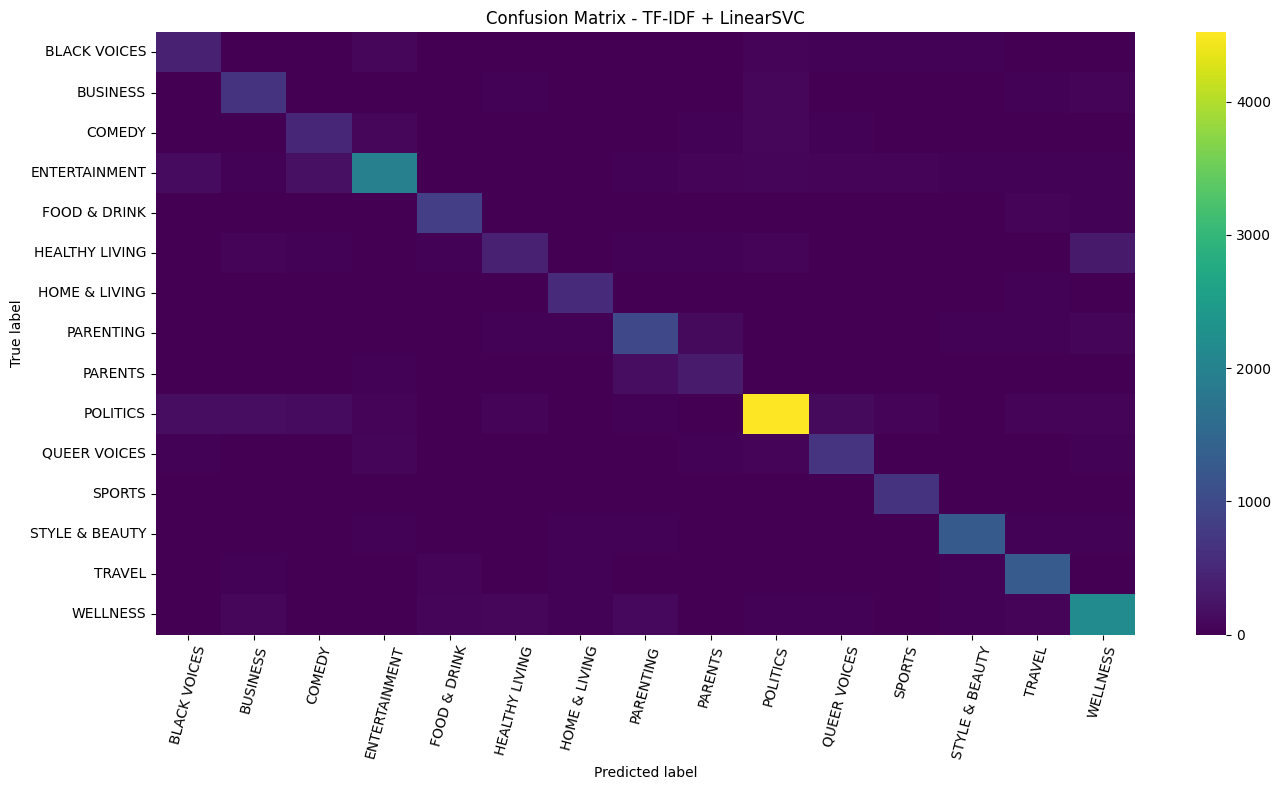

In [19]:
test_metrics = {
    "accuracy": accuracy_score(y_test, y_test_pred),
    "macro_f1": f1_score(y_test, y_test_pred, average="macro", zero_division=0),
    "weighted_f1": f1_score(y_test, y_test_pred, average="weighted", zero_division=0),
    "macro_precision": precision_score(y_test, y_test_pred, average="macro", zero_division=0),
    "macro_recall": recall_score(y_test, y_test_pred, average="macro", zero_division=0)
}

print("Test metrics:")
print(test_metrics)

# =========================
# Classification report
# =========================
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        zero_division=0
    )
)

# Lưu classification report thành DataFrame
report_dict = classification_report(
    y_test,
    y_test_pred,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()

display(report_df)

# =========================
# Confusion matrix
# =========================
target_names = sorted(y_test.unique())

cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=target_names
)

plt.figure(figsize=(14, 8))

sns.heatmap(
    cm,
    annot=False,
    fmt="d",
    cmap="viridis",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title("Confusion Matrix - TF-IDF + LinearSVC")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(rotation=75)
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig("confusion_matrix_tfidf_linearsvc.png", dpi=150)
plt.show()